In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

env: ANYWIDGET_HMR=1


In [8]:
import celldega as dega
import numpy as np
import pandas as pd
from anndata import AnnData
print(dega.__version__)

0.13.0a9


In [9]:
# --- Create dummy test data ---
def create_test_adata():
    np.random.seed(0)
    n_cells = 10
    x = np.random.uniform(0, 100, size=n_cells)
    y = np.random.uniform(0, 100, size=n_cells)

    obs = pd.DataFrame({
        "leiden": np.random.choice(["A", "B", "C"], size=n_cells)
    }, index=[f"cell_{i}" for i in range(n_cells)])

    var = pd.DataFrame(index=["dummy_gene"])
    X = np.random.poisson(1, (n_cells, 1))

    adata = AnnData(X=X, obs=obs, var=var)
    adata.obsm["spatial"] = np.vstack([x, y]).T

    return adata

# --- Run test ---
adata = create_test_adata()
gdf_niche, gdf_hex = dega.nbhd.cluster_hex_tiles_leiden(adata, radius=15, resolution=0.5, n_neighbors=5)

# --- Show results ---
print("Niche-level clusters:")
display(gdf_niche)

print("Hex tile assignments:")
display(gdf_hex)

Calculating NBP
Niche-level clusters:


,name,geometry
0,niche_0,"MULTIPOLYGON (((64.32491 -5.47816, 64.32491 9...."
1,niche_1,"MULTIPOLYGON (((51.33453 -12.97816, 38.34415 -..."


Hex tile assignments:


,name,geometry,leiden,prop_A,prop_B,prop_C
0,hex_0,"POLYGON ((64.32491 9.52184, 51.33453 17.02184,...",1,0.000000,0.500000,0.500000
1,hex_1,"POLYGON ((90.30568 9.52184, 77.31530 17.02184,...",0,1.000000,0.000000,0.000000
2,hex_2,"POLYGON ((51.33453 32.02184, 38.34415 39.52184...",0,0.000000,0.000000,0.000000
3,hex_3,"POLYGON ((77.31530 32.02184, 64.32491 39.52184...",0,0.000000,0.000000,0.000000
4,hex_4,"POLYGON ((64.32491 54.52184, 51.33453 62.02184...",1,0.000000,1.000000,0.000000
5,hex_5,"POLYGON ((90.30568 54.52184, 77.31530 62.02184...",0,1.000000,0.000000,0.000000
6,hex_6,"POLYGON ((51.33453 77.02184, 38.34415 84.52184...",0,0.000000,0.000000,0.000000
7,hex_7,"POLYGON ((77.31530 77.02184, 64.32491 84.52184...",0,0.000000,0.000000,0.000000
8,hex_8,"POLYGON ((103.29606 77.02184, 90.30568 84.5218...",1,0.000000,1.000000,0.000000
9,hex_9,"POLYGON ((38.34415 99.52184, 25.35377 107.0218...",0,1.000000,0.000000,0.000000


<Axes: >

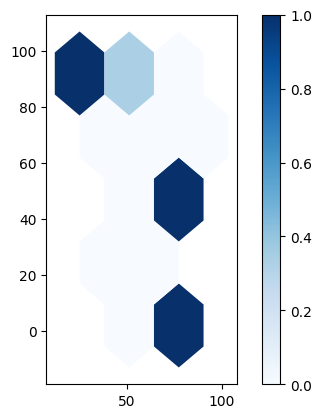

In [10]:
gdf_hex.plot(column="prop_A", cmap="Blues", legend=True)

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_hex_clusters(gdf_hex, gdf_niche):
    """Plot hexagonal tiles colored by Leiden cluster and overlay niche outlines."""
    fig, ax = plt.subplots(figsize=(8, 8))

    # Work on a copy to avoid modifying original GeoDataFrame
    gdf_hex_plot = gdf_hex.copy()

    # Convert leiden to string (for consistent coloring keys)
    gdf_hex_plot["leiden_str"] = gdf_hex_plot["leiden"].astype(str)
    clusters = sorted(gdf_hex_plot["leiden_str"].unique())

    # Generate color map
    cmap = cm.get_cmap("tab10", len(clusters))
    color_map = {cluster: cmap(i) for i, cluster in enumerate(clusters)}

    # Map colors to a new column
    gdf_hex_plot["color"] = gdf_hex_plot["leiden_str"].map(lambda x: color_map.get(x, "#CCCCCC"))

    # Plot hex tiles
    gdf_hex_plot.plot(ax=ax, color=gdf_hex_plot["color"], edgecolor="black", linewidth=0.3)

    # Plot niche outlines
    if gdf_niche is not None and not gdf_niche.empty:
        gdf_niche.boundary.plot(ax=ax, color="red", linewidth=1.2)

        # Label niches at centroid (skip if geometry is MultiPolygon)
        for _, row in gdf_niche.iterrows():
            geom = row["geometry"]
            if geom.geom_type == "Polygon":
                x, y = geom.centroid.coords[0]
                ax.text(x, y, row["name"], ha="center", va="center", fontsize=9, color="red")
            elif geom.geom_type == "MultiPolygon":
                # Label at largest polygon's centroid
                largest = max(geom.geoms, key=lambda g: g.area)
                x, y = largest.centroid.coords[0]
                ax.text(x, y, row["name"], ha="center", va="center", fontsize=9, color="red")

    ax.set_title("Hex Tiles with Leiden Clusters and Niche Boundaries", fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

/var/folders/_6/bhs42vt57t1dkb59k4sy0p440000gp/T/ipykernel_46473/2648579213.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab10", len(clusters))


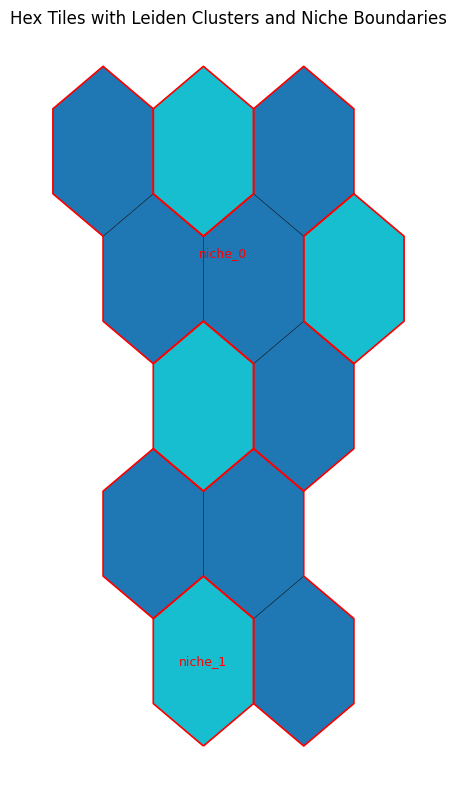

In [13]:
plot_hex_clusters(gdf_hex, gdf_niche)